In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import foscat.scat_cov as sc
import healpy as hp

f=sc.funct(KERNELSZ=3)

(49152,)


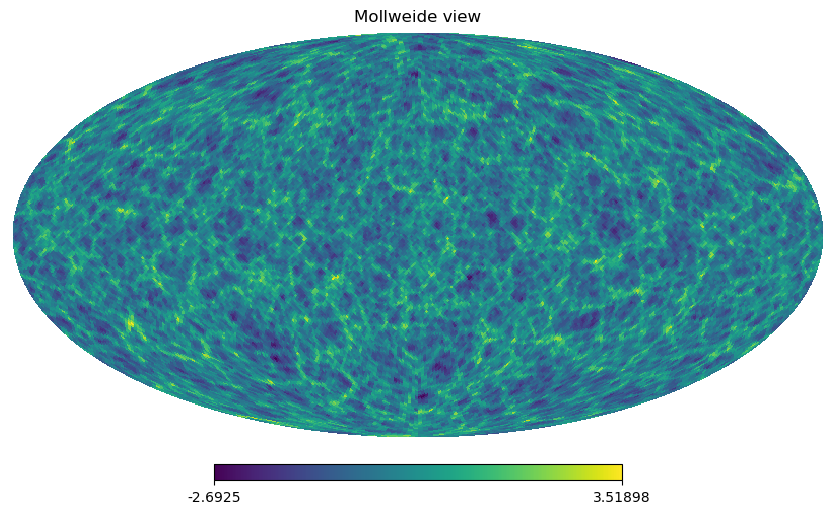

In [2]:
im = np.load('./heal_im.npy')
print(im.shape)
hp.mollview(im,nest=True)

In [3]:
from healpix_analyse.alm_latlon import build_rings_from_latlon,anafast_latlon
import torch

In [5]:
nside=128
#im=np.random.randn(12*nside**2)
im=hp.ud_grade(im,nside)
t,p=hp.pix2ang(nside,np.arange(12*nside**2))
ring_theta, ring_phi_list, ring_counts, idx = build_rings_from_latlon(t, p)


Text(0.5, 0, 'C(l)')

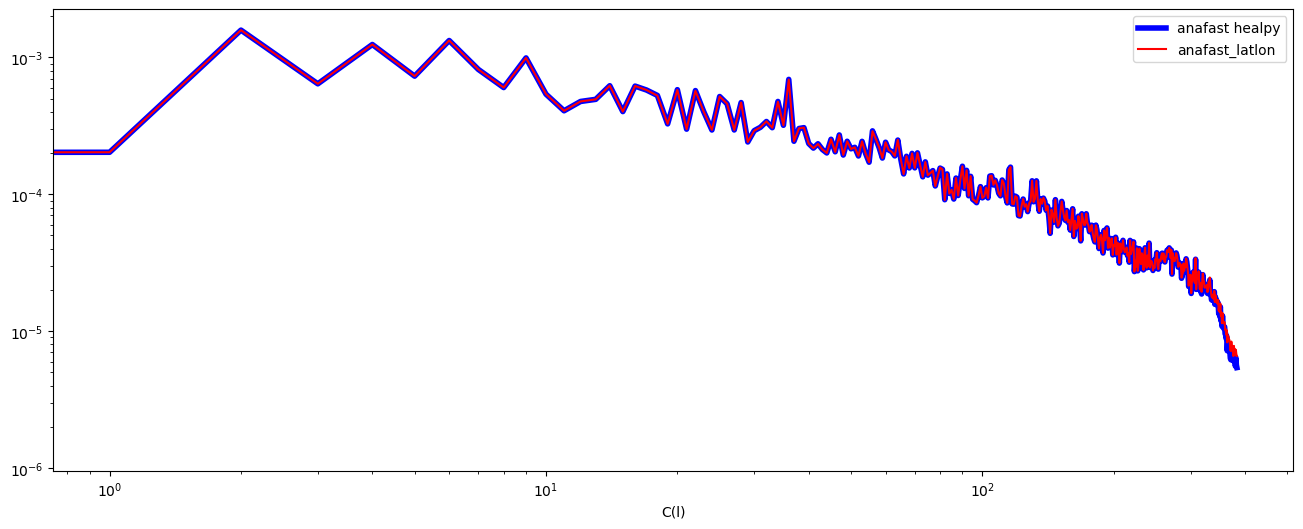

In [6]:

cl2 = hp.anafast(im)
cl = anafast_latlon(im[idx], ring_theta, ring_phi_list, ring_counts,lmax=3*nside-1)

plt.figure(figsize=(16,6))
plt.plot(cl2,lw=4,label='anafast healpy',color='b')
plt.plot(cl.cpu().numpy(),label='anafast_latlon',color='r')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Multipole')
plt.legend()
plt.xlabel('C(l)')

In [7]:
try:
    import cdsapi
except:
    !pip install xarray cdsapi

In [8]:
#!/usr/bin/env python
import xarray as xr

try:
    dsG = xr.open_dataset("outputGT2m.grib")
except:
    c = cdsapi.Client()
    
    c.retrieve("reanalysis-era5-complete", {
        "class": "ea",
        "date": "2025-01-01",
        "expver": "1",
        "levtype": "sfc",
        "number": "0/1/2/3/4/5/6/7/8/9",
        "param": "167.128",
        "step": "12",
        "stream": "enda",
        "time": "09:00:00",
        "type": "4v",
        "grid":"N256",
    }, "outputGT2m.grib")
    dsG = xr.open_dataset("outputGT2m.grib")

dsG

<xarray.Dataset> Size: 20MB
Dimensions:     (number: 10, values: 348528)
Coordinates:
  * number      (number) int64 80B 0 1 2 3 4 5 6 7 8 9
    time        datetime64[ns] 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    latitude    (values) float64 3MB ...
    longitude   (values) float64 3MB ...
    valid_time  datetime64[ns] 8B ...
Dimensions without coordinates: values
Data variables:
    t2m         (number, values) float32 14MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-18T21:33 GRIB to CDM+CF via cfgrib-0.9.1...

In [9]:
ring_theta, ring_phi_list, ring_counts, idx = build_rings_from_latlon(np.deg2rad(90.0-dsG.latitude.values),
                         np.deg2rad(dsG.longitude.values))

In [10]:
cl = anafast_latlon(torch.tensor(dsG.t2m.values[0,idx],device='cpu'), ring_theta, ring_phi_list, ring_counts,quadrature='gauss_legendre')

Text(0.5, 0, 'C(l)')

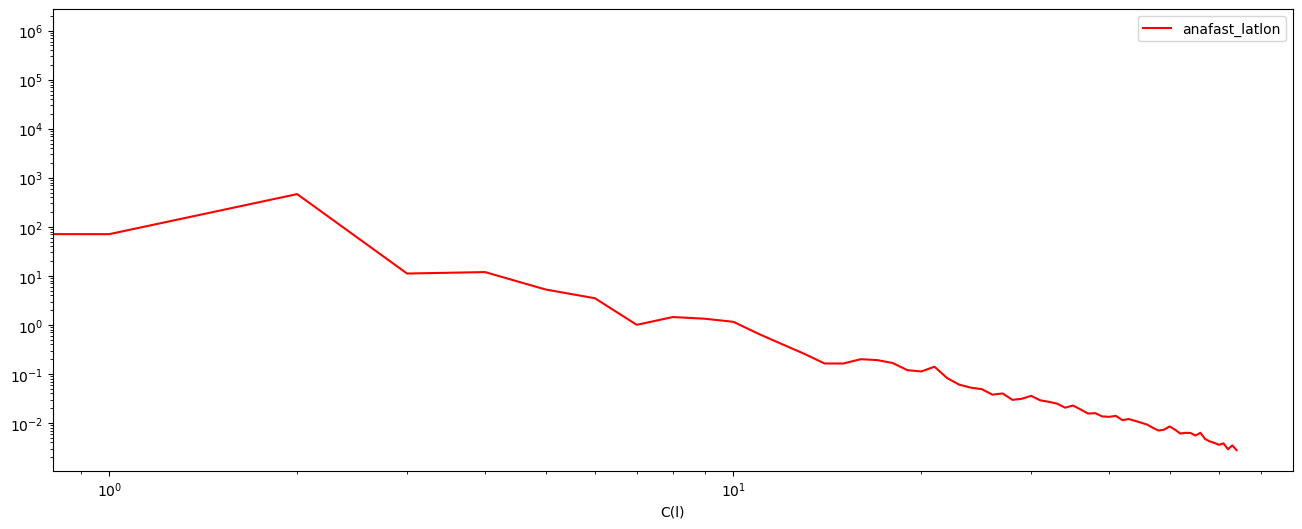

In [12]:
plt.figure(figsize=(16,6))
plt.plot(cl.cpu().numpy(),label='anafast_latlon',color='r')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Multipole')
plt.legend()
plt.xlabel('C(l)')

In [15]:
import healpy as hp
tmp=np.random.randn(12*1024**2)
im_new=hp.smoothing(tmp,np.deg2rad(5.0))
im_new=hp.get_interp_val(im_new,
                         (np.deg2rad(90.0-dsG.latitude.values)),
                         np.deg2rad(dsG.longitude.values))

im_new2=tmp
im_new2=hp.get_interp_val(im_new2,
                         (np.deg2rad(90.0-dsG.latitude.values)),
                         np.deg2rad(dsG.longitude.values))

In [16]:
cl1 = anafast_latlon(im_new[idx], ring_theta, ring_phi_list, ring_counts)
cl2 = anafast_latlon(im_new2[idx], ring_theta, ring_phi_list, ring_counts)

Text(0.5, 0, 'C(l)')

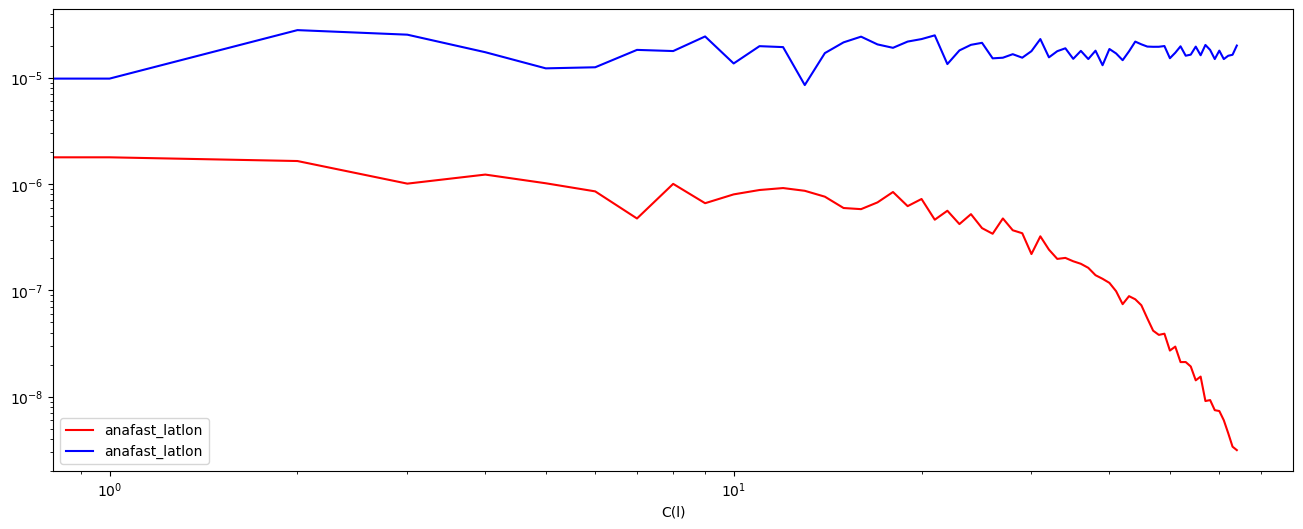

In [17]:
plt.figure(figsize=(16,6))
plt.plot(cl1.cpu().numpy(),label='anafast_latlon',color='r')
plt.plot(cl2.cpu().numpy(),label='anafast_latlon',color='b')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Multipole')
plt.legend()
plt.xlabel('C(l)')

In [18]:
from healpix_analyse.convol import HealPixConv
from healpix_analyse.down   import HealPixDown
from healpix_analyse.up     import HealPixUp

import torch
nside = 64

down = HealPixDown(nside_in=nside)
conv = HealPixConv(nside=nside, in_channels=1, out_channels=16)
up   = HealPixUp(nside_in=nside//2)

x = torch.randn(8, 12 * nside**2)       # [B, N]
x_feat = conv(x)                         # [B, 16, N]
x_down, ids_out = down(x_feat[:, 0, :]) # [B, N/4]
x_up, ids_fine  = up(x_down)            # [B, N]

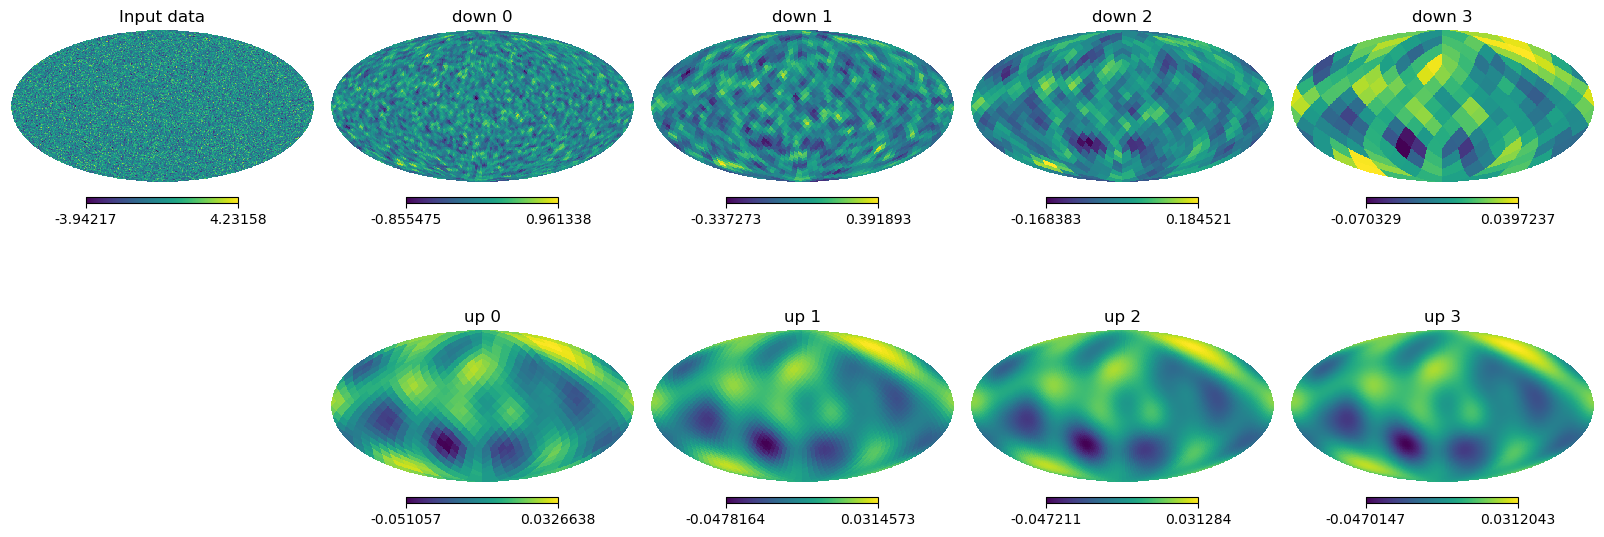

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
x=np.random.randn(12*nside**2)
x_down=x
plt.figure(figsize=(16,6))
hp.mollview(x_down,nest=True,sub=(2,5,1),hold=False,title='Input data')
lnside=nside
for k in range(4):
    down = HealPixDown(nside_in=lnside)
    x_down, _ = down(x_down)
    lnside/=2
    hp.mollview(x_down,nest=True,sub=(2,5,2+k),hold=False,title='down %d'%(k))

x_up=x_down
for k in range(4):
    up   = HealPixUp(nside_in=lnside)
    x_up, _  = up(x_up)
    lnside*=2
    hp.mollview(x_up,nest=True,sub=(2,5,7+k),hold=False,title='up %d'%(k))

HealPixConv(nside=64, in=1, out=1, kernel_sz=5, P=25, G=4, gauge='phi', partial=False)

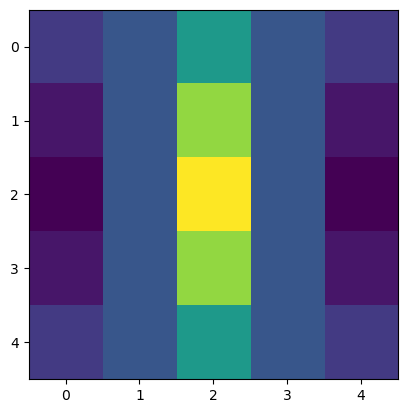

In [20]:
import numpy as np
from healpix_analyse.convol import HealPixConv
import matplotlib.pyplot as plt
nside = 64
kernelsz=5
conv = HealPixConv(nside=nside, in_channels=1, out_channels=1, n_gauges=4, kernel_sz=kernelsz,gauge_type='phi')

# 25-point Gaussian: center gets more weight than the 8 neighbours
x,y = np.meshgrid(np.arange(kernelsz)-kernelsz//2,np.arange(kernelsz)-kernelsz//2)

W = np.zeros([1,1,kernelsz*kernelsz])
W[0,0] = (np.exp(-0.25*(x**2+y**2))*np.cos(0.5*(x)*np.pi)).ravel()
W[0,0] -= W[0,0].mean()

plt.imshow(W[0,0].reshape(kernelsz,kernelsz))
conv.set_kernel(W)


(4, 49152)


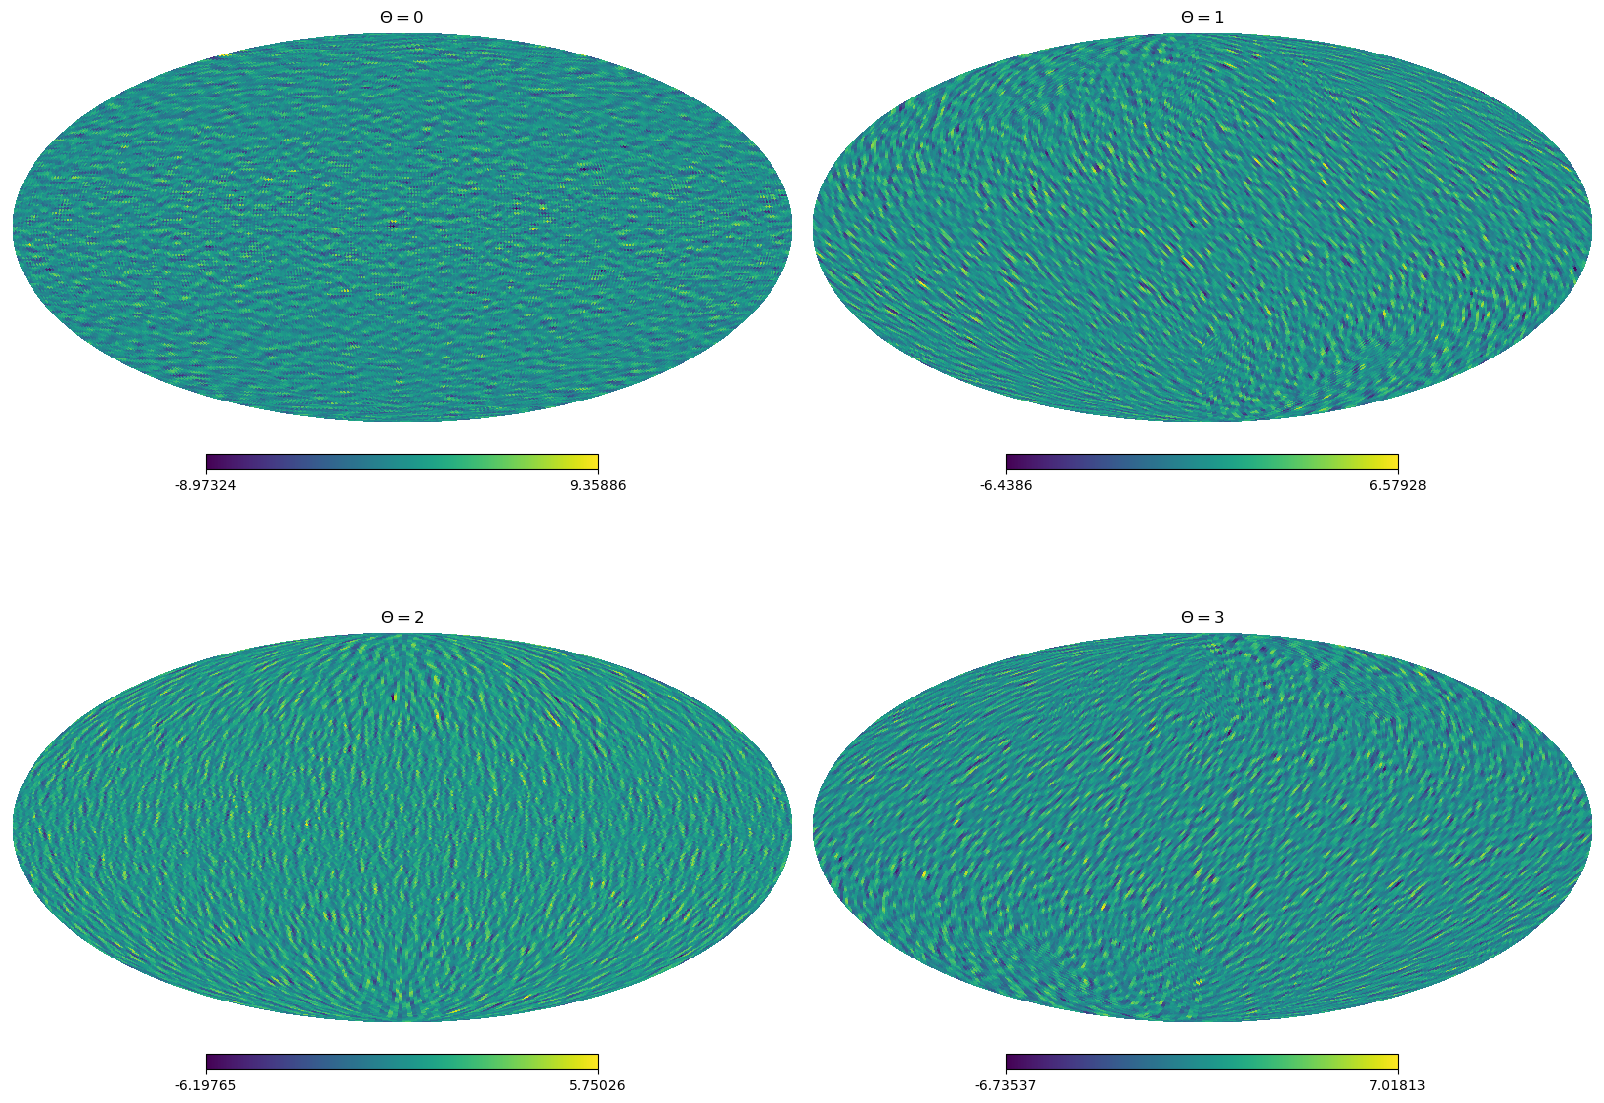

In [21]:
import healpy as hp
import numpy as np
sky = np.random.randn(12 * nside**2).astype(np.float32)
sky_smooth = conv(sky)     # returns np.ndarray [N]
print(sky_smooth.shape)
plt.figure(figsize=(16,12))
for k in range(4):
    hp.mollview(sky_smooth[k],nest=True,sub=(2,2,1+k),hold=False,title=r'$\Theta=%d$'%(k))    

(4, 49152)


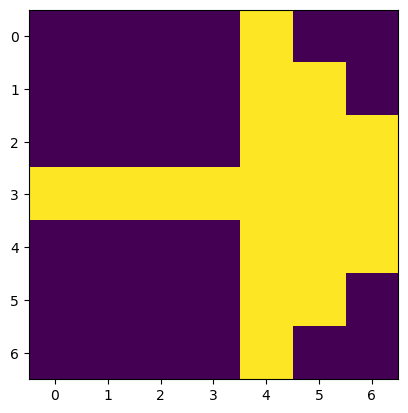

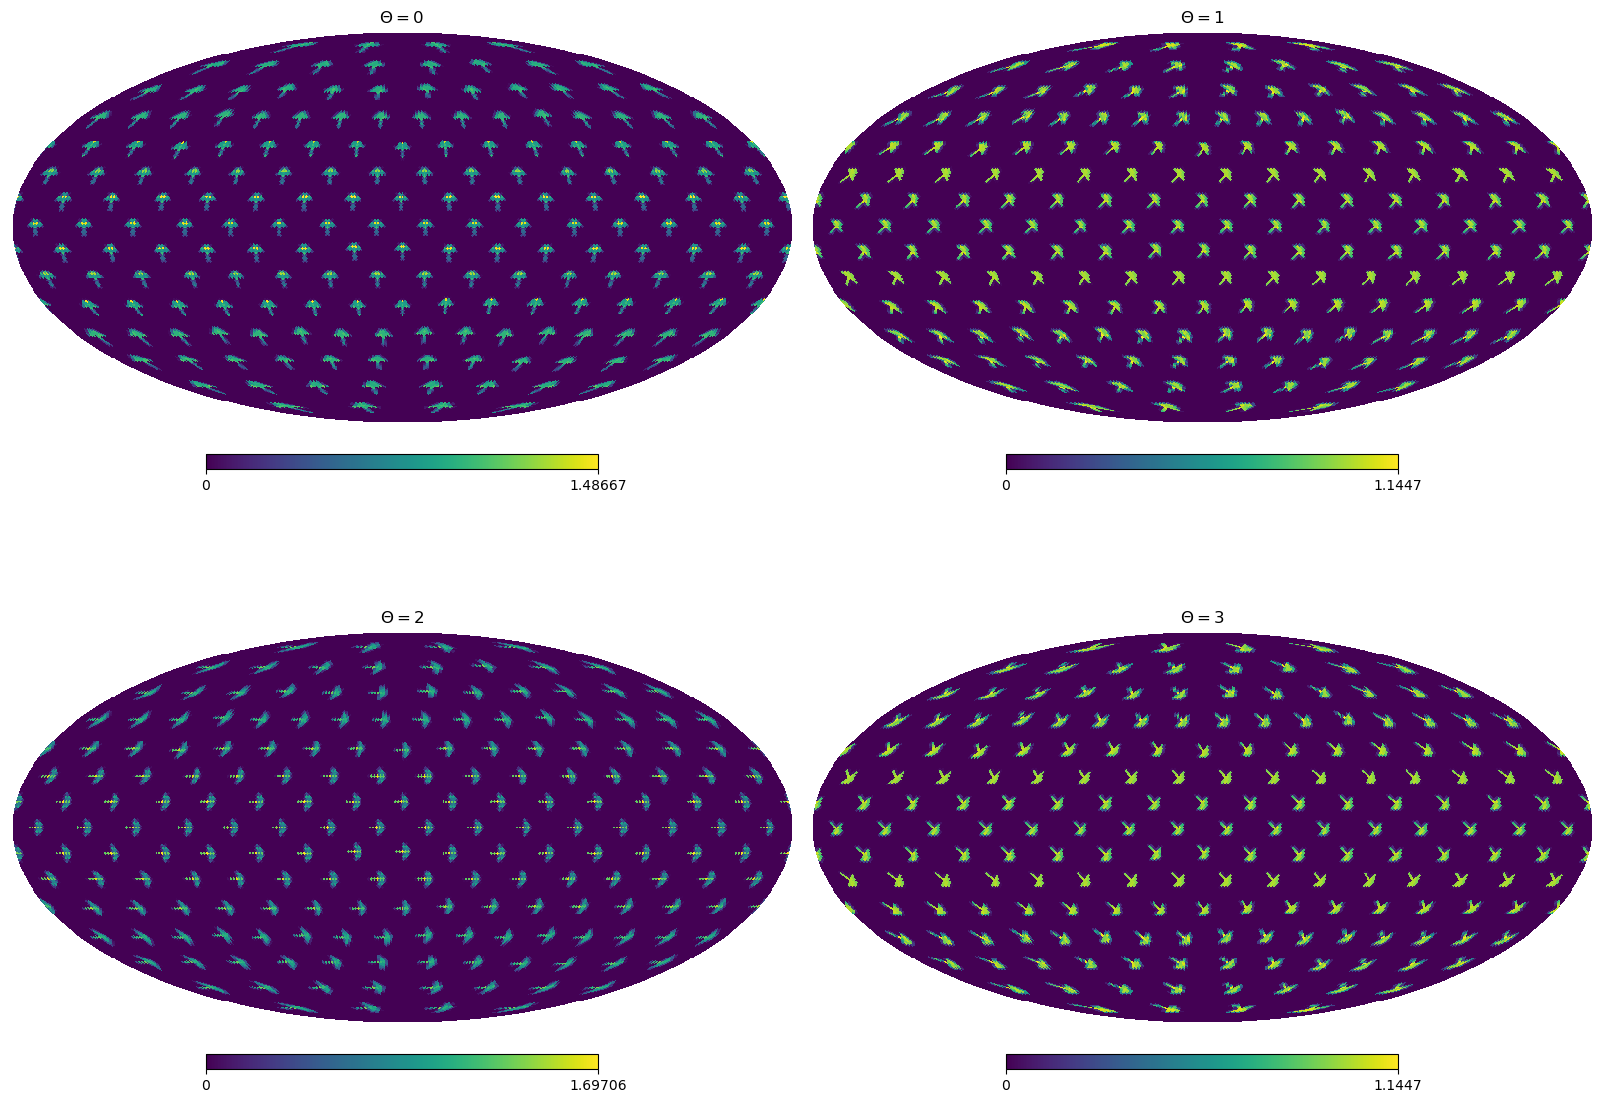

In [22]:
nside = 64
kernelsz=7
conv = HealPixConv(nside=nside, in_channels=1, out_channels=1, n_gauges=4, kernel_sz=kernelsz,gauge_type='phi')

# 25-point Gaussian: center gets more weight than the 8 neighbours
W = np.array([[0,0,0,0,1,0,0],
              [0,0,0,0,1,1,0],
              [0,0,0,0,1,1,1],
              [1,1,1,1,1,1,1],
              [0,0,0,0,1,1,1],
              [0,0,0,0,1,1,0],
              [0,0,0,0,1,0,0]]).ravel().astype('float32').reshape(1,1,kernelsz*kernelsz)
    

plt.imshow(W[0,0].reshape(kernelsz,kernelsz))
conv.set_kernel(W)

sky = np.zeros([12 * nside**2],dtype=np.float32)
tc,pc=hp.pix2ang(4,np.arange(12*4**2),nest=True)
sky[hp.ang2pix(nside,tc,pc,nest=True)]=1.0
sky_smooth = conv(sky)     # returns np.ndarray [N]
print(sky_smooth.shape)
plt.figure(figsize=(16,12))
for k in range(4):
    hp.mollview(sky_smooth[k],nest=True,sub=(2,2,1+k),hold=False,title=r'$\Theta=%d$'%(k))    # (49152,)

(4, 49152)


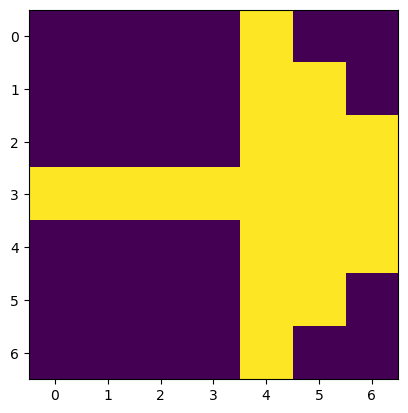

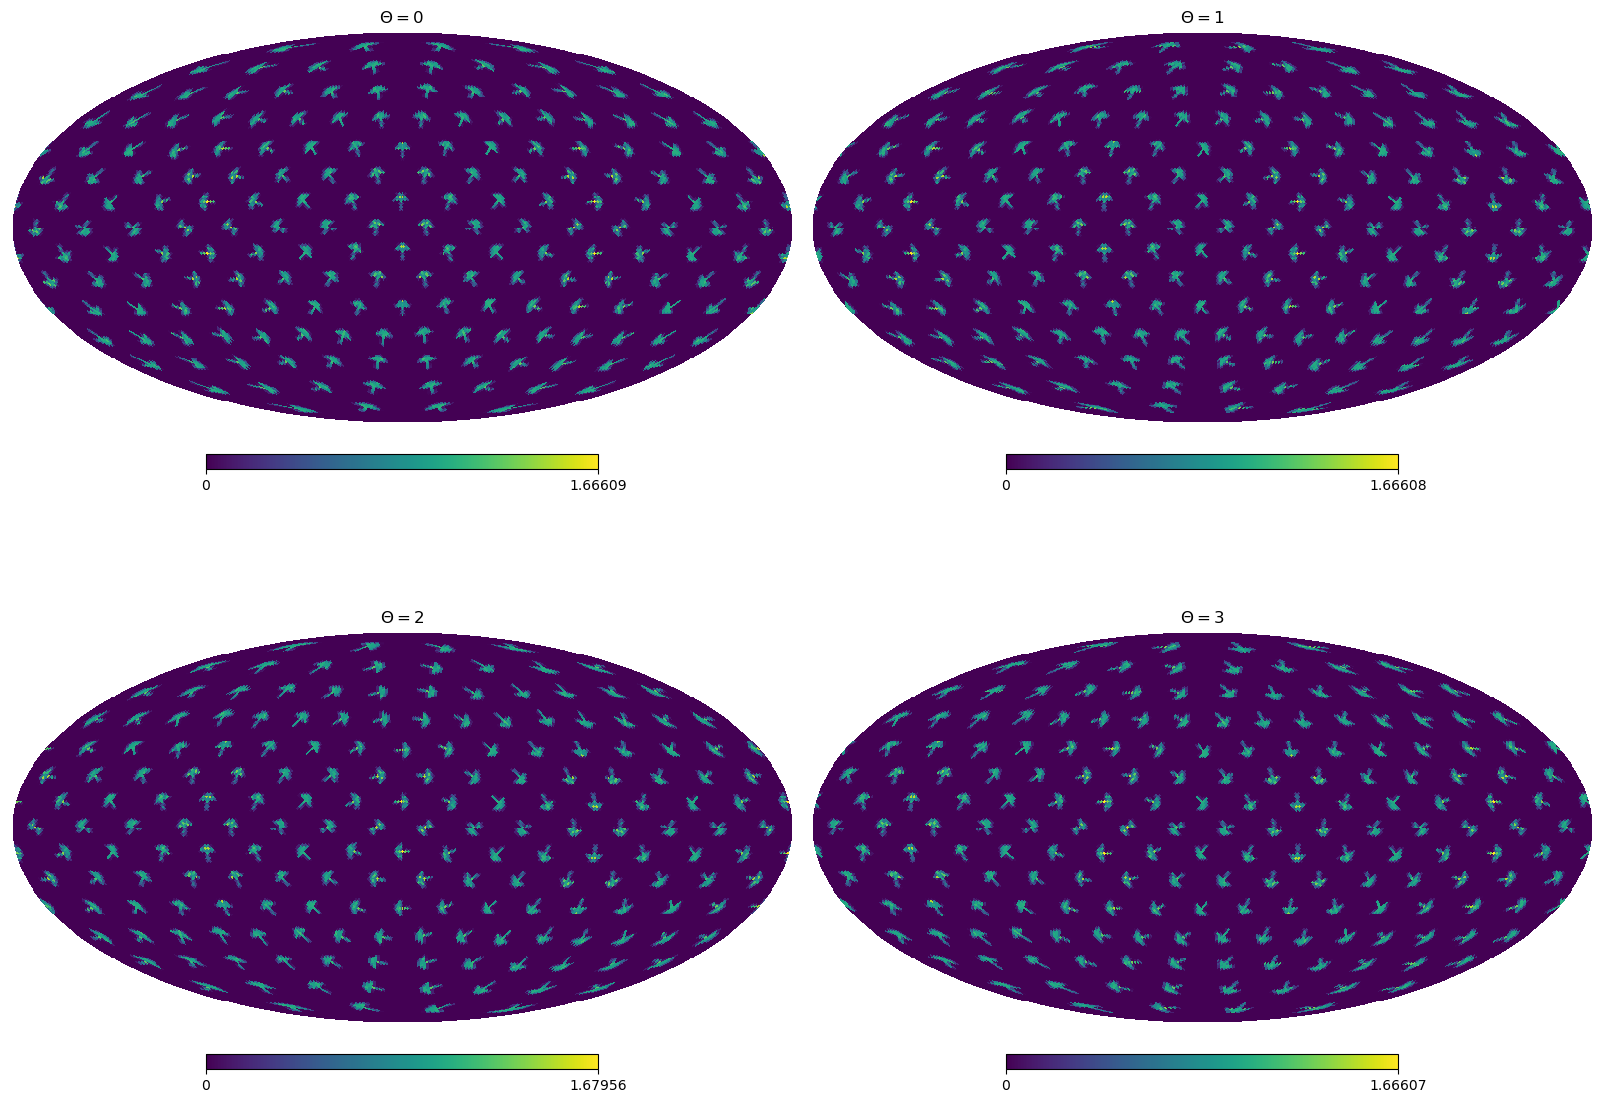

In [23]:
nside = 64
kernelsz=7
conv = HealPixConv(nside=nside, in_channels=1, out_channels=1, n_gauges=4, kernel_sz=kernelsz,gauge_type='cosmo')

# 25-point Gaussian: center gets more weight than the 8 neighbours
W = np.array([[0,0,0,0,1,0,0],
              [0,0,0,0,1,1,0],
              [0,0,0,0,1,1,1],
              [1,1,1,1,1,1,1],
              [0,0,0,0,1,1,1],
              [0,0,0,0,1,1,0],
              [0,0,0,0,1,0,0]]).ravel().astype('float32').reshape(1,1,kernelsz*kernelsz)
    

plt.imshow(W[0,0].reshape(kernelsz,kernelsz))
conv.set_kernel(W)

sky = np.zeros([12 * nside**2],dtype=np.float32)
tc,pc=hp.pix2ang(4,np.arange(12*4**2),nest=True)
sky[hp.ang2pix(nside,tc,pc,nest=True)]=1.0
sky_smooth = conv(sky)     # returns np.ndarray [N]
print(sky_smooth.shape)
plt.figure(figsize=(16,12))
for k in range(4):
    hp.mollview(sky_smooth[k],nest=True,sub=(2,2,1+k),hold=False,title=r'$\Theta=%d$'%(k))    # (49152,)

In [24]:
# Placer les singularités loin de l'Europe (vers le Pacifique et l'océan Indien)
conv = HealPixConv(nside=64, in_channels=1, out_channels=16,
                   gauge_type="projected_ref",
                   ref_direction=[0, 1, 0])  # singularités à φ=90° et φ=270°

(4, 49152)


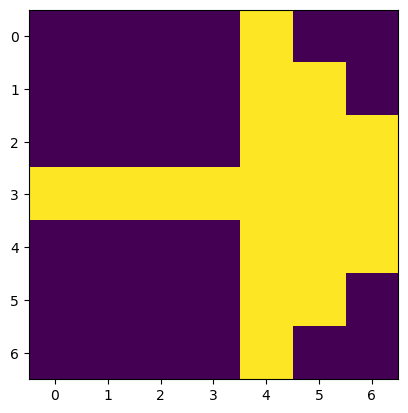

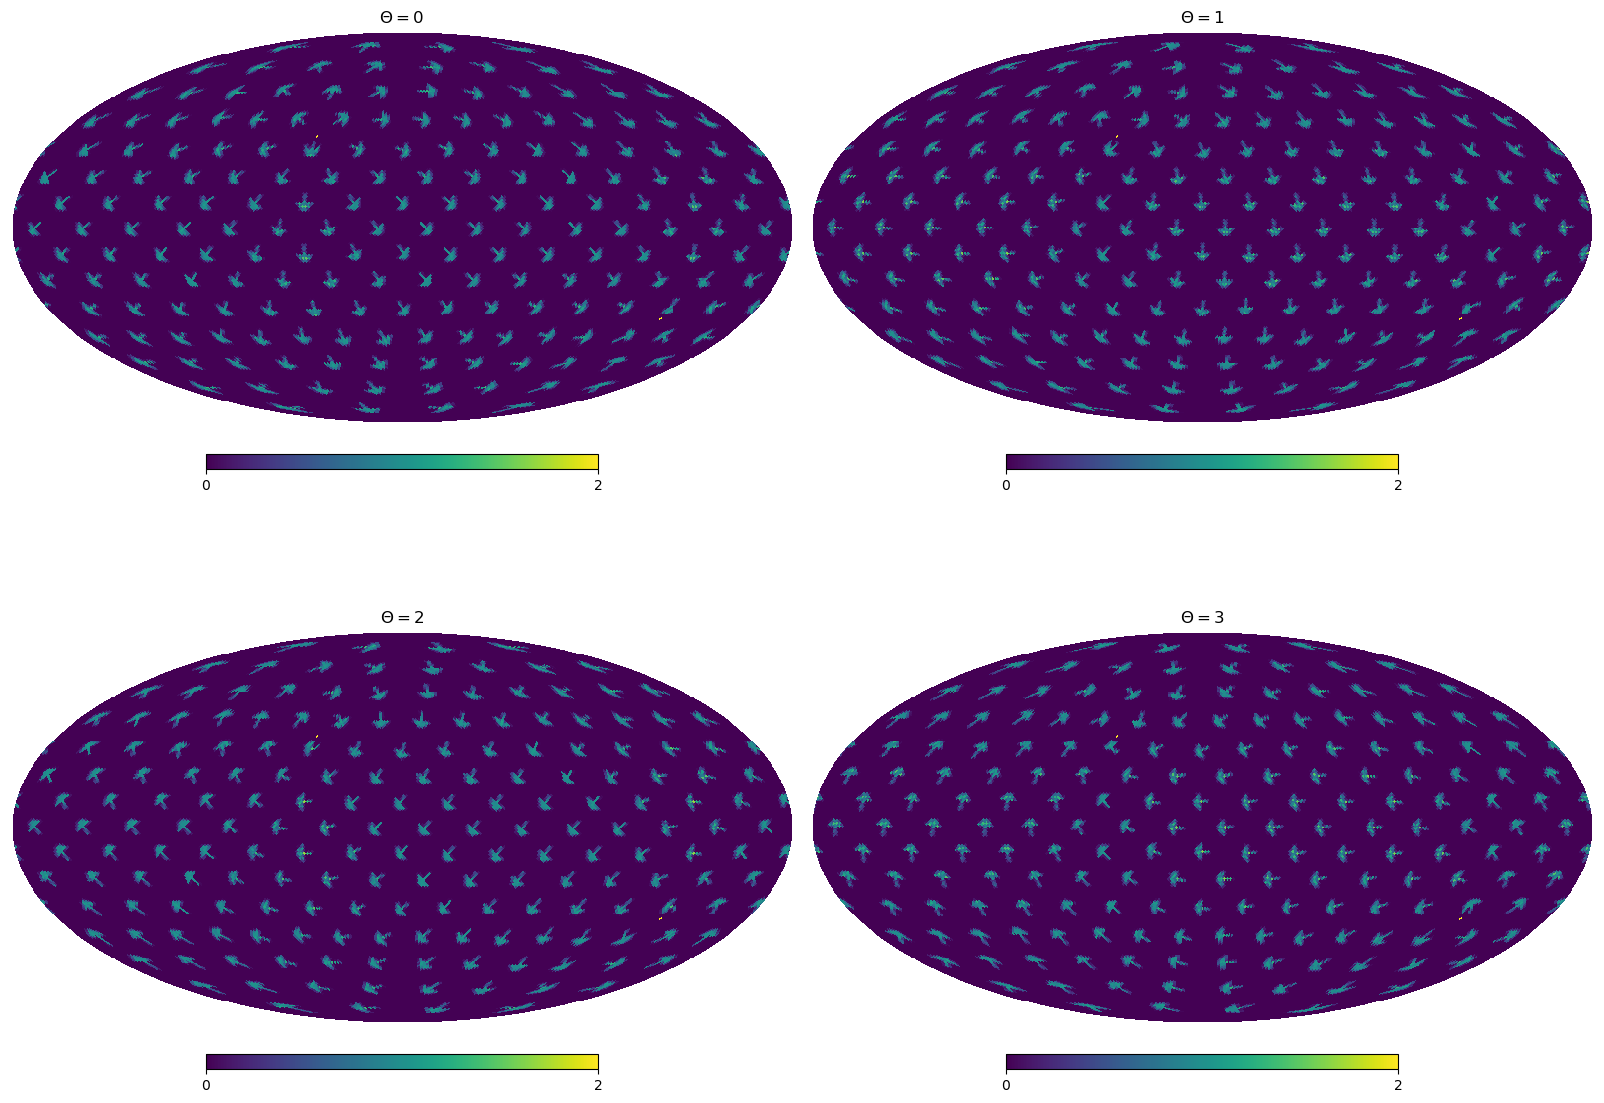

In [29]:
kernelsz=7
conv = HealPixConv(nside=nside, in_channels=1, out_channels=1, n_gauges=4, kernel_sz=kernelsz,gauge_type="projected_ref",
                  ref_direction=[1/np.sqrt(3),1/np.sqrt(3),1/np.sqrt(3)])

center_idx=hp.vec2pix(nside,1/np.sqrt(3),1/np.sqrt(3),1/np.sqrt(3),nest=True)
acenter_idx=hp.vec2pix(nside,-1/np.sqrt(3),-1/np.sqrt(3),-1/np.sqrt(3),nest=True)

# 25-point Gaussian: center gets more weight than the 8 neighbours
W = np.array([[0,0,0,0,1,0,0],
              [0,0,0,0,1,1,0],
              [0,0,0,0,1,1,1],
              [1,1,1,1,1,1,1],
              [0,0,0,0,1,1,1],
              [0,0,0,0,1,1,0],
              [0,0,0,0,1,0,0]]).ravel().astype('float32').reshape(1,1,kernelsz*kernelsz)
    

plt.imshow(W[0,0].reshape(kernelsz,kernelsz))
conv.set_kernel(W)

sky = np.zeros([12 * nside**2],dtype=np.float32)
tc,pc=hp.pix2ang(4,np.arange(12*4**2),nest=True)
sky[hp.ang2pix(nside,tc,pc,nest=True)]=1.0
sky_smooth = conv(sky)     # returns np.ndarray [N]
print(sky_smooth.shape)
plt.figure(figsize=(16,12))
for k in range(4):
    tmp=sky_smooth[k]
    tmp[center_idx]=2.
    tmp[acenter_idx]=2.
    hp.mollview(tmp,nest=True,sub=(2,2,1+k),hold=False,title=r'$\Theta=%d$'%(k))    # (49152,)